# Build arXiv Tesseract OCR Corpus

Notebook này parse PDF từ arXiv bằng **Tesseract OCR** (không dùng text-based parsers như PyMuPDF/pypdf):

- Crawl/tải PDF từ **arXiv** theo **cùng domain**
- Render PDF thành ảnh (PNG)
- Extract text bằng **Tesseract OCR** 
- Tạo benchmark:
  - **positive pairs**: cùng tài liệu (từ các trang/bản chạy khác nhau)
  - **hard negatives**: khác tài liệu nhưng cùng domain
  - **online stream benchmark**

> Ghi chú:
> - Tesseract OCR hoạt động trên **ảnh trang**, không trực tiếp trên text layer
> - Phù hợp cho scan PDFs hoặc PDFs không có text layer tốt


## 0. Cài thư viện cơ bản

Cell này cài Tesseract, pdf2image, pytesseract và các thư viện hỗ trợ.

In [1]:
%pip -q install requests feedparser pdf2image pytesseract pillow tqdm pandas

Note: you may need to restart the kernel to use updated packages.


## 1. Cài Tesseract và Poppler (Windows)

Trên **Windows** cần cài thủ công:
- **Tesseract**: https://github.com/UB-Mannheim/tesseract/wiki → tải bản `.exe`, chọn Add to PATH
- **Poppler**: https://github.com/oschwartz10612/poppler-windows/releases → giải nén, thêm `bin/` vào PATH

Hoặc dùng lệnh dưới nếu đã cài **winget** / **Chocolatey**.

In [2]:
import subprocess, sys, shutil

# Kiểm tra xem đã cài chưa
tess_path = shutil.which("tesseract")
poppler_path = shutil.which("pdfinfo") or shutil.which("pdftoppm")

if tess_path:
    print(f"✅ Tesseract: {tess_path}")
    result = subprocess.run(["tesseract", "--version"], capture_output=True, text=True)
    print(result.stdout or result.stderr)
else:
    print("❌ Tesseract chưa cài!")
    print("   → Windows: tải tại https://github.com/UB-Mannheim/tesseract/wiki")
    print("   → Linux:   apt-get install tesseract-ocr")

if poppler_path:
    print(f"✅ Poppler: {poppler_path}")
else:
    print("❌ Poppler chưa cài!")
    print("   → Windows: tải tại https://github.com/oschwartz10612/poppler-windows/releases")
    print("              Giải nén, thêm thư mục bin/ vào PATH hoặc điền POPPLER_PATH bên dưới")
    print("   → Linux:   apt-get install poppler-utils")


❌ Tesseract chưa cài!
   → Windows: tải tại https://github.com/UB-Mannheim/tesseract/wiki
   → Linux:   apt-get install tesseract-ocr
❌ Poppler chưa cài!
   → Windows: tải tại https://github.com/oschwartz10612/poppler-windows/releases
              Giải nén, thêm thư mục bin/ vào PATH hoặc điền POPPLER_PATH bên dưới
   → Linux:   apt-get install poppler-utils


## 2. Import và cấu hình

In [3]:
from pathlib import Path
import re
import os
import json
import time
import math
import hashlib
import random
import pandas as pd
from tqdm.auto import tqdm
from itertools import combinations
import pytesseract
from PIL import Image
from pdf2image import convert_from_path

random.seed(42)

# ===== Cấu hình đường dẫn Tesseract/Poppler (Windows) =====
# BƯỚC 1: Chạy installer "tesseract-ocr-w64-setup-5.5.0.20241111.exe" trước
# BƯỚC 2: Sau khi cài xong, trỏ vào tesseract.EXE (không phải file installer)
TESSERACT_CMD = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
POPPLER_PATH = r"C:\Users\pntha\Downloads\Release-25.12.0-0\poppler-25.12.0\Library\bin"

if TESSERACT_CMD:
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_CMD

# Kiểm tra Tesseract
try:
    ver = pytesseract.get_tesseract_version()
    print(f"✅ Tesseract version: {ver}")
except Exception as e:
    print(f"❌ Tesseract lỗi: {e}")
    print("   → Hãy chạy installer tesseract-ocr-w64-setup-5.5.0.20241111.exe trước!")
    print("   → Sau đó TESSERACT_CMD phải trỏ vào: C:\\Program Files\\Tesseract-OCR\\tesseract.exe")

# Kiểm tra Poppler
import shutil
poppler_ok = shutil.which("pdfinfo") or shutil.which("pdftoppm") or POPPLER_PATH
if poppler_ok:
    print(f"✅ Poppler OK")
else:
    print(f"❌ Poppler chưa cài/chưa trong PATH")

# ===== Folder cấu hình =====
PREV_BASE_DIR = Path("arxiv_ocr_benchmark_workspace")
PREV_PDF_DIR = PREV_BASE_DIR / "pdfs"
PREV_META_DIR = PREV_BASE_DIR / "metadata"

BASE_DIR = Path("arxiv_tesseract_ocr_benchmark_workspace")
IMG_DIR = BASE_DIR / "page_images"
PARSED_DIR = BASE_DIR / "parsed_jsonl"
BENCH_DIR = BASE_DIR / "benchmark"

for d in [IMG_DIR, PARSED_DIR, BENCH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nLấy PDF từ: {PREV_PDF_DIR} ({len(list(PREV_PDF_DIR.glob('*.pdf')))} PDFs)")
print(f"Output: {BASE_DIR}")


✅ Tesseract version: 5.5.0.20241111
✅ Poppler OK

Lấy PDF từ: arxiv_ocr_benchmark_workspace\pdfs (1578 PDFs)
Output: arxiv_tesseract_ocr_benchmark_workspace


c:\Users\pntha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load metadata từ notebook PyMuPDF/pypdf

Lấy metadata và PDFs đã tải từ notebook trước, không cần tải lại.

In [4]:
# Load metadata từ file JSONL/CSV của notebook PyMuPDF/pypdf
meta_jsonl_path = PREV_META_DIR / "arxiv_search_results_multi_query.jsonl"
meta_csv_path = PREV_META_DIR / "arxiv_search_results_multi_query.csv"

if meta_jsonl_path.exists():
    rows = []
    with open(meta_jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} records từ JSONL")
elif meta_csv_path.exists():
    df = pd.read_csv(meta_csv_path)
    print(f"Loaded {len(df)} records từ CSV")
else:
    print("❌ Không tìm thấy metadata. Kiểm tra lại folder:")
    print(f"  {meta_jsonl_path}")
    print(f"  {meta_csv_path}")

# Lọc chỉ những PDFs có sẵn trong folder
available_pdfs = set(p.stem for p in PREV_PDF_DIR.glob("*.pdf"))
df = df[df["arxiv_id"].isin(available_pdfs)].reset_index(drop=True)

print(f"\nSố PDF có sẵn: {len(df)}")
df[["arxiv_id", "title", "primary_category"]].head(10)


Loaded 1579 records từ JSONL

Số PDF có sẵn: 1578


,arxiv_id,title,primary_category
0,2604.01212v1,$\texttt{YC-Bench}$: Benchmarking AI Agents fo...,cs.CL
1,2604.01195v1,ORBIT: Scalable and Verifiable Data Generation...,cs.CL
2,2604.01193v1,Embarrassingly Simple Self-Distillation Improv...,cs.CL
3,2604.01181v1,True (VIS) Lies: Analyzing How Generative AI R...,cs.HC
4,2604.01029v1,Revision or Re-Solving? Decomposing Second-Pas...,cs.SE
5,2604.00986v1,Do Phone-Use Agents Respect Your Privacy?,cs.CR
6,2604.00913v1,Benchmarking and Mechanistic Analysis of Visio...,cs.CV
7,2604.00890v1,Beyond Symbolic Solving: Multi Chain-of-Though...,cs.AI
8,2604.00778v1,From Early Encoding to Late Suppression: Inter...,cs.CL
9,2604.00698v1,Learning to Hint for Reinforcement Learning,cs.LG


## 4. Render PDF thành images

In [5]:
def render_pdf_to_images(pdf_path: str, out_dir: Path, dpi: int = 150, max_pages: int | None = None):
    """Render PDF pages to PNG images. POPPLER_PATH được lấy từ biến global."""
    pdf_stem = Path(pdf_path).stem
    page_dir = out_dir / pdf_stem
    page_dir.mkdir(parents=True, exist_ok=True)

    convert_kwargs = {"dpi": dpi}
    if POPPLER_PATH:
        convert_kwargs["poppler_path"] = POPPLER_PATH

    images = convert_from_path(pdf_path, **convert_kwargs)
    if max_pages is not None:
        images = images[:max_pages]

    paths = []
    for i, img in enumerate(images, start=1):
        out_path = page_dir / f"page_{i:04d}.png"
        if not out_path.exists():
            img.save(out_path)
        paths.append(out_path)
    return paths


## 5. Tesseract OCR parser

In [6]:

# Cấu hình OCR
OCR_DPI = 100          # Giảm từ 150 → 100 (~44% ít pixel hơn, tốc độ tăng ~2x)
OCR_LANG = "eng"
OCR_MAX_PAGES = None   # None = tất cả trang; đặt số nguyên để giới hạn
NUM_WORKERS = 8     # Số luồng song song (tăng nếu CPU nhiều core)

# Tesseract config: OEM 1 = LSTM only (nhanh hơn OEM 3), PSM 3 = auto
TESS_CONFIG = "--oem 1 --psm 3"

def extract_with_tesseract(
    pdf_path: str,
    image_dir: Path,
    dpi: int = 150,
    max_pages: int | None = None,
    lang: str = "eng",
):
    """Extract text từ PDF bằng Tesseract OCR"""
    img_paths = render_pdf_to_images(pdf_path, image_dir, dpi=dpi, max_pages=max_pages)

    pages = []
    for i, img_path in enumerate(img_paths, start=1):
        try:
            txt = pytesseract.image_to_string(Image.open(img_path), lang=lang, config=TESS_CONFIG)
        except Exception as e:
            txt = ""
        pages.append({"page_num": i, "text": txt})

    return {
        "parser": "tesseract_ocr",
        "page_count": len(pages),
        "pages": pages,
        "text": "\n\n".join(p["text"] for p in pages),
    }

# === Test thử 1 PDF ===
test_pdfs = list(PREV_PDF_DIR.glob("*.pdf"))
if test_pdfs:
    print(f"Test OCR trên: {test_pdfs[0].name}")
    try:
        result = extract_with_tesseract(str(test_pdfs[0]), IMG_DIR, dpi=OCR_DPI, max_pages=1)
        print(f"✅ Thành công - page_count={result['page_count']}, char_count={len(result['text'])}")
        print("Text mẫu (100 chars):", repr(result['text'][:100]))
    except Exception as e:
        print(f"❌ Lỗi: {e}")


Test OCR trên: 2507.21563v3.pdf
✅ Thành công - page_count=1, char_count=3998
Text mẫu (100 chars): '13 Aug 2025\n\n2507.21563v3 [cs.IR]\n\narXiv\n\nEnhancing Graph-based Recommendations with\nMajority- Votin'


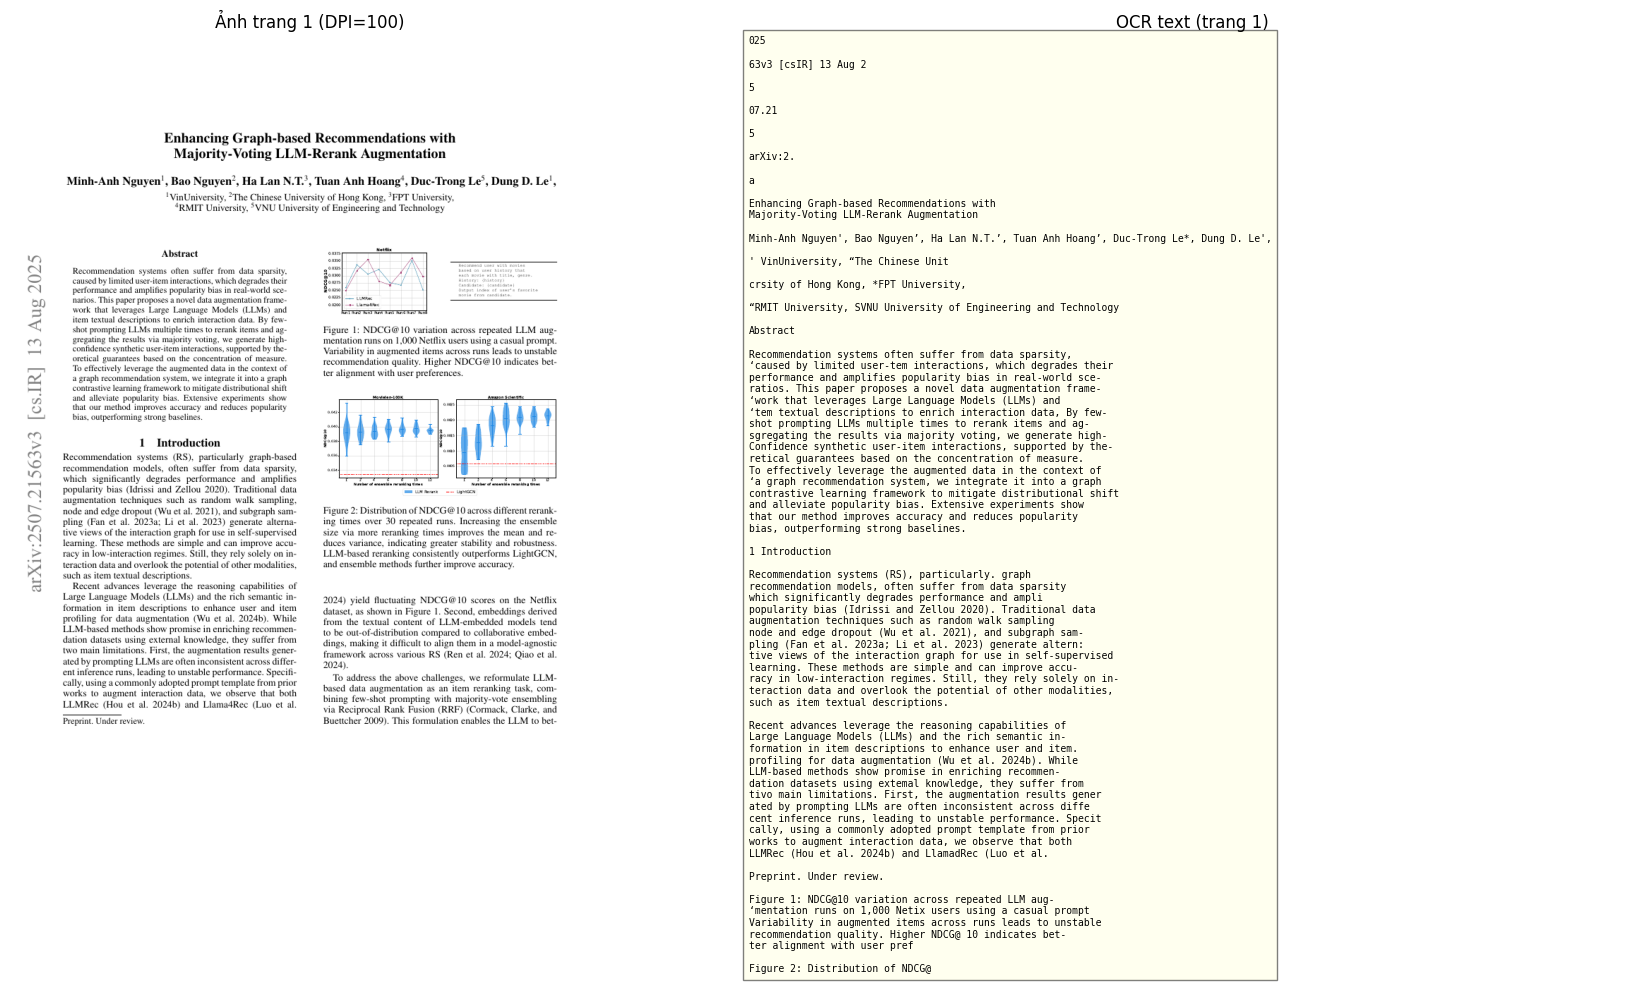


--- Full OCR text (page 1) ---
025

63v3 [csIR] 13 Aug 2

5

07.21

5

arXiv:2.

a

Enhancing Graph-based Recommendations with
Majority-Voting LLM-Rerank Augmentation

Minh-Anh Nguyen', Bao Nguyen’, Ha Lan N.T.’, Tuan Anh Hoang’, Duc-Trong Le*, Dung D. Le',

' VinUniversity, “The Chinese Unit

crsity of Hong Kong, *FPT University,

“RMIT University, SVNU University of Engineering and Technology

Abstract

Recommendation systems often suffer from data sparsity,
‘caused by limited user-tem interactions, which degrades their
performance and amplifies popularity bias in real-world sce-
ratios. This paper proposes a novel data augmentation frame-
‘work that leverages Large Language Models (LLMs) and
‘tem textual descriptions to enrich interaction data, By few-
shot prompting LLMs multiple times to rerank items and ag-
sgregating the results via majority voting, we generate high-
Confidence synthetic user-item interactions, supported by the-
retical guarantees based on the concentration of 

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualize_ocr_result(pdf_path: str, page_num: int = 1, dpi: int = 150):
    """Hiển thị ảnh trang PDF và text OCR song song"""
    # Render ảnh
    convert_kwargs = {"dpi": dpi, "first_page": page_num, "last_page": page_num}
    if POPPLER_PATH:
        convert_kwargs["poppler_path"] = POPPLER_PATH
    images = convert_from_path(pdf_path, **convert_kwargs)
    if not images:
        print("Không render được ảnh")
        return
    img = images[0]

    # OCR text
    txt = pytesseract.image_to_string(img, lang=OCR_LANG)

    # Hiển thị
    fig = plt.figure(figsize=(18, 10))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"Ảnh trang {page_num} (DPI={dpi})", fontsize=12)

    ax_txt = fig.add_subplot(gs[1])
    ax_txt.axis("off")
    ax_txt.set_title(f"OCR text (trang {page_num})", fontsize=12)
    ax_txt.text(
        0, 1, txt[:3000],
        transform=ax_txt.transAxes,
        fontsize=7,
        verticalalignment="top",
        fontfamily="monospace",
        wrap=True,
        bbox=dict(facecolor="lightyellow", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()
    print(f"\n--- Full OCR text (page {page_num}) ---")
    print(txt)

# Chọn PDF và trang muốn xem
test_pdfs = list(PREV_PDF_DIR.glob("*.pdf"))
if test_pdfs:
    visualize_ocr_result(str(test_pdfs[0]), page_num=1, dpi=OCR_DPI)


## 6. Chuẩn hóa text và đóng gói output

In [8]:
def normalize_text(text: str) -> str:
    """Chuẩn hóa text"""
    if text is None:
        return ""
    text = text.replace("\x00", " ")
    text = re.sub(r"\r\n?", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def sha1_text(text: str) -> str:
    """Tính SHA1 hash của text"""
    return hashlib.sha1(text.encode("utf-8", errors="ignore")).hexdigest()

def build_record(meta_row: dict, pdf_path: str, parsed: dict):
    """Build record đầy đủ"""
    text = normalize_text(parsed["text"])
    return {
        "doc_id": meta_row["arxiv_id"],
        "source_pdf": str(pdf_path),
        "parser_name": parsed["parser"],
        "text": text,
        "text_sha1": sha1_text(text),
        "char_count": len(text),
        "page_count": parsed["page_count"],
        "pages": parsed["pages"],
        "metadata": {
            "title": meta_row["title"],
            "summary": meta_row["summary"],
            "published": meta_row["published"],
            "updated": meta_row["updated"],
            "authors": meta_row["authors"],
            "pdf_url": meta_row["pdf_url"],
            "primary_category": meta_row["primary_category"],
            "categories": meta_row["categories"],
            "source": "arxiv",
        }
    }

## 7. Parse toàn bộ PDF bằng Tesseract

In [9]:

import concurrent.futures
import threading

records = []
errors = []
_lock = threading.Lock()

meta_by_id = {row["arxiv_id"]: row for _, row in df.iterrows()}

# Resume: chỉ load records HỢP LỆ (char_count > 0)
done_ids = set()
resume_path = PARSED_DIR / "arxiv_tesseract_ocr_all.jsonl"
valid_records = []

if resume_path.exists():
    for line in open(resume_path, encoding="utf-8"):
        try:
            doc = json.loads(line)
            if doc.get("char_count", 0) > 0:
                done_ids.add(doc["doc_id"])
                valid_records.append(doc)
        except Exception:
            pass
    print(f"▶ Resume: {len(done_ids)} records hợp lệ, bỏ qua {len(done_ids)} PDF đã xong")
    
    # Ghi lại file chỉ với records hợp lệ (xóa các record rỗng từ lần chạy lỗi trước)
    with open(resume_path, "w", encoding="utf-8", errors="replace") as f:
        for r in valid_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"✅ Đã dọn dẹp file: giữ lại {len(valid_records)} records hợp lệ")

records = valid_records

all_pdfs = sorted(PREV_PDF_DIR.glob("*.pdf"))
todo_pdfs = [p for p in all_pdfs if p.stem in meta_by_id and p.stem not in done_ids]
print(f"\nCần xử lý: {len(todo_pdfs)} PDFs (bỏ qua {len(done_ids)} đã xong)")

def process_one(pdf_path: Path):
    arxiv_id = pdf_path.stem
    meta_row = meta_by_id[arxiv_id]
    try:
        parsed = extract_with_tesseract(
            pdf_path=str(pdf_path),
            image_dir=IMG_DIR,
            dpi=OCR_DPI,
            max_pages=OCR_MAX_PAGES,
            lang=OCR_LANG,
        )
        rec = build_record(meta_row, str(pdf_path), parsed)
        return rec, None
    except Exception as e:
        return None, {"doc_id": arxiv_id, "pdf_path": str(pdf_path), "error": str(e)}

# Ghi incremental vào file
out_f = open(resume_path, "a", encoding="utf-8", errors="replace")

from tqdm.auto import tqdm
pbar = tqdm(total=len(todo_pdfs), desc="OCR")

with concurrent.futures.ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    future_to_pdf = {executor.submit(process_one, p): p for p in todo_pdfs}
    for future in concurrent.futures.as_completed(future_to_pdf):
        rec, err = future.result()
        with _lock:
            if rec:
                records.append(rec)
                out_f.write(json.dumps(rec, ensure_ascii=False) + "\n")
                out_f.flush()
            if err:
                errors.append(err)
        pbar.update(1)

pbar.close()
out_f.close()

print(f"\n✅ Tesseract OCR hoàn tất: {len(records)} documents")
print(f"❌ Lỗi: {len(errors)} documents")
if errors[:3]:
    print("\nLỗi đầu tiên:", errors[0])


▶ Resume: 1530 records hợp lệ, bỏ qua 1530 PDF đã xong
✅ Đã dọn dẹp file: giữ lại 1530 records hợp lệ

Cần xử lý: 48 PDFs (bỏ qua 1530 đã xong)


OCR: 100%|██████████| 48/48 [10:35<00:00, 13.25s/it]


✅ Tesseract OCR hoàn tất: 1578 documents
❌ Lỗi: 0 documents


## 8. Xuất JSONL outputs

Xuất toàn bộ Tesseract OCR records, có thể ghép với PyMuPDF/pypdf outputs

In [15]:

# File đã được ghi incremental trong cell trên, chỉ cần thống kê
all_jsonl_path = PARSED_DIR / "arxiv_tesseract_ocr_all.jsonl"
print(f"Output: {all_jsonl_path}")
print(f"Tổng {len(records)} records")

# Thống kê
parsed_df = pd.DataFrame([
    {
        "doc_id": r["doc_id"],
        "char_count": r["char_count"],
        "page_count": r["page_count"],
        "text_sha1": r["text_sha1"],
        "primary_category": r["metadata"]["primary_category"],
    }
    for r in records
])

print("\nThống kê:")
print(f"Trung bình ký tự per doc: {parsed_df['char_count'].mean():.0f}")
print(f"Trung bình trang per doc: {parsed_df['page_count'].mean():.1f}")
print(f"Số doc char_count=0: {(parsed_df['char_count']==0).sum()}")
print(f"Số tài liệu: {len(parsed_df)}")


Output: arxiv_tesseract_ocr_benchmark_workspace\parsed_jsonl\arxiv_tesseract_ocr_all.jsonl
Tổng 1578 records

Thống kê:
Trung bình ký tự per doc: 62961
Trung bình trang per doc: 19.6
Số doc char_count=0: 0
Số tài liệu: 1578


## 9. Tạo hard negative pairs cùng domain

In [ ]:
# Load lại từ file JSONL để đảm bảo có đủ dữ liệu (tránh phụ thuộc vào biến `records` trong memory)
resume_path = PARSED_DIR / "arxiv_tesseract_ocr_all.jsonl"

loaded_records = []
if resume_path.exists():
    with open(resume_path, encoding="utf-8") as f:
        for line in f:
            try:
                doc = json.loads(line)
                if doc.get("char_count", 0) > 0:
                    loaded_records.append(doc)
            except Exception:
                pass
    print(f"Load từ file: {len(loaded_records)} records hợp lệ")
else:
    print("⚠ Không tìm thấy file JSONL. Dùng biến records trong memory.")
    loaded_records = records

mini_records = [
    {
        "doc_id": r["doc_id"],
        "text_sha1": r["text_sha1"],
        "char_count": r["char_count"],
        "primary_category": r["metadata"]["primary_category"],
        "title": r["metadata"]["title"],
    }
    for r in loaded_records
]

print(f"mini_records: {len(mini_records)} docs")
print("Phân bổ theo category:")
from collections import Counter
for cat, cnt in Counter(r["primary_category"] for r in mini_records).most_common():
    print(f"  {cat}: {cnt}")


Số positive pairs: 0


## 10. Xuất pair benchmark

In [17]:
def build_hard_negatives(records, negatives_per_doc=2):
    """Tạo hard negatives từ cùng category"""
    by_cat = {}
    for r in records:
        cat = r["primary_category"]
        by_cat.setdefault(cat, []).append(r)

    negatives = []
    seen = set()

    for cat, items in by_cat.items():
        for a in items:
            candidates = [x for x in items if x["doc_id"] != a["doc_id"]]
            random.shuffle(candidates)
            picked = 0
            for b in candidates:
                key = tuple(sorted([(a["doc_id"], ), (b["doc_id"], )]))
                if key in seen:
                    continue
                seen.add(key)
                negatives.append({
                    "left_doc_id": a["doc_id"],
                    "right_doc_id": b["doc_id"],
                    "left_category": a["primary_category"],
                    "right_category": b["primary_category"],
                    "label": 0,
                    "pair_type": "same_domain_hard_negative",
                })
                picked += 1
                if picked >= negatives_per_doc:
                    break
    return pd.DataFrame(negatives)

hard_negative_df = build_hard_negatives(mini_records, negatives_per_doc=2)
print(f"Số hard negative pairs: {len(hard_negative_df)}")
hard_negative_df.head()

Số hard negative pairs: 3067


,left_doc_id,right_doc_id,left_category,right_category,label,pair_type
0,2508.05664v1,2603.29897v1,cs.IR,cs.IR,0,same_domain_hard_negative
1,2508.05664v1,2603.24226v2,cs.IR,cs.IR,0,same_domain_hard_negative
2,2508.05512v1,2603.02555v1,cs.IR,cs.IR,0,same_domain_hard_negative
3,2508.05512v1,2603.03770v1,cs.IR,cs.IR,0,same_domain_hard_negative
4,2508.01514v1,2603.11008v1,cs.IR,cs.IR,0,same_domain_hard_negative


## 9. Tạo hard negative pairs cùng domain

In [18]:
# Kết hợp hard negatives (không có positive pairs vì chỉ 1 parser)
pair_benchmark_df = hard_negative_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

pair_csv = BENCH_DIR / "tesseract_hard_negative_benchmark.csv"
pair_jsonl = BENCH_DIR / "tesseract_hard_negative_benchmark.jsonl"

pair_benchmark_df.to_csv(pair_csv, index=False, encoding="utf-8")
with open(pair_jsonl, "w", encoding="utf-8") as f:
    for row in pair_benchmark_df.to_dict(orient="records"):
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Xuất pair benchmark: {pair_csv}")
print(f"Xuất pair benchmark: {pair_jsonl}")
print(pair_benchmark_df["label"].value_counts(dropna=False))

Xuất pair benchmark: arxiv_tesseract_ocr_benchmark_workspace\benchmark\tesseract_hard_negative_benchmark.csv
Xuất pair benchmark: arxiv_tesseract_ocr_benchmark_workspace\benchmark\tesseract_hard_negative_benchmark.jsonl
label
0    3067
Name: count, dtype: int64


## 11. Online stream benchmark

Một document stream đơn giản: lần đầu một doc xuất hiện = label 0 (negative), các lần sau = label 1 (duplicate)

In [19]:
stream_df = pd.DataFrame(mini_records).sample(frac=1.0, random_state=42).reset_index(drop=True)

seen = set()
labels = []
for _, row in stream_df.iterrows():
    is_dup = 1 if row["doc_id"] in seen else 0
    labels.append(is_dup)
    seen.add(row["doc_id"])

stream_df["label"] = labels
stream_df["stream_type"] = "tesseract_ocr_stream"

stream_csv = BENCH_DIR / "tesseract_stream_benchmark.csv"
stream_jsonl = BENCH_DIR / "tesseract_stream_benchmark.jsonl"

stream_df.to_csv(stream_csv, index=False, encoding="utf-8")
with open(stream_jsonl, "w", encoding="utf-8") as f:
    for row in stream_df.to_dict(orient="records"):
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Xuất stream benchmark: {stream_csv}")
print(f"Xuất stream benchmark: {stream_jsonl}")
print(stream_df["label"].value_counts(dropna=False))
print(f"\nTotal stream records: {len(stream_df)}")

Xuất stream benchmark: arxiv_tesseract_ocr_benchmark_workspace\benchmark\tesseract_stream_benchmark.csv
Xuất stream benchmark: arxiv_tesseract_ocr_benchmark_workspace\benchmark\tesseract_stream_benchmark.jsonl
label
0    1578
Name: count, dtype: int64

Total stream records: 1578


## 12. Ghi chú: Near-Duplicate với Tesseract

### Cách dùng notebook này:

1. **Chạy notebook PyMuPDF/pypdf trước** (tải PDFs, tạo metadata)
2. **Chạy notebook Tesseract OCR này** (dùng lại PDFs, tạo near-duplicates)

### Output:

- `arxiv_tesseract_ocr_all.jsonl` - Tesseract OCR records (cùng schema với PyMuPDF/pypdf)
- `tesseract_hard_negative_benchmark.jsonl/csv` - Hard negatives  
- `tesseract_stream_benchmark.jsonl/csv` - Stream benchmark

### Ghép outputs:

Bạn có **2 bộ JSON schema giống nhau**:
```python
# Folder 1: arxiv_ocr_benchmark_workspace/parsed_jsonl/
# - arxiv_multi_parser_ocr_all.jsonl (PyMuPDF + pypdf)

# Folder 2: arxiv_tesseract_ocr_benchmark_workspace/parsed_jsonl/
# - arxiv_tesseract_ocr_all.jsonl (Tesseract OCR)

# Ghép:
cat arxiv_ocr_benchmark_workspace/parsed_jsonl/arxiv_multi_parser_ocr_all.jsonl \
    arxiv_tesseract_ocr_benchmark_workspace/parsed_jsonl/arxiv_tesseract_ocr_all.jsonl \
    > combined_multi_parser.jsonl
```

Này bây giờ là **near-duplicate benchmark** :
- Cùng PDF, khác parser (text-based vs OCR)
- text_sha1 sẽ khác → label = dedup positives